In [2]:
import numpy as np
import modules.loaddata
import modules.nuwro
import modules.utils
import matplotlib.pyplot as plt

In [3]:
modules.nuwro.TestStupidCoordinateConversion(120)

In [4]:
lfg_q, lfg_data = modules.loaddata.load_response_functions("../week4/results/", "C12_CC_LFG")

In [5]:
lfg_data[4][1]

array([[ 0.    ,  0.8   ,  1.6   ,  2.4   ,  3.2   ,  4.    ,  4.8   ,
         5.6   ,  6.4   ,  7.2   ,  8.    ,  8.8   ,  9.6   , 10.4   ,
        11.2   , 12.    , 12.8   , 13.6   , 14.4   , 15.2   , 16.    ,
        16.8   , 17.6   , 18.4   , 19.2   , 20.    , 20.8   , 21.6   ,
        22.4   , 23.2   , 24.    , 24.8   , 25.6   , 26.4   , 27.2   ,
        28.    , 28.8   , 29.6   , 30.4   , 31.2   , 32.    , 32.8   ,
        33.6   , 34.4   , 35.2   , 36.    , 36.8   , 37.6   , 38.4   ,
        39.2   , 40.    ],
       [ 0.    ,  4.701 , 16.1167, 28.8938, 41.7048, 53.0857, 61.8903,
        72.8554, 76.0029, 77.7212, 77.3209, 69.2069, 61.1972, 42.8895,
        14.6638,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.   

In [6]:
funcs = modules.loaddata.build_spectral_interpolator(lfg_q, lfg_data)

In [23]:
maxval = 1200
stepsize = 10
steps = int(maxval/stepsize)

qcoords = np.arange(0, 1200, stepsize)
wcoords = np.arange(0, 1200, stepsize)
# w_coords = w_coords.flatten()
# q_coords = q_coords.flatten()

q_idxs, w_idxs = np.meshgrid(np.arange(0, steps), np.arange(0, steps))

outarrays = [[0]*steps*steps for _ in range(5)]

for (w_idx, q_idx) in zip(w_idxs.flatten(), q_idxs.flatten()):
    index = modules.nuwro.Stupid_2D_to_1D(q_idx, w_idx, steps)
    q = qcoords[q_idx]
    w = wcoords[w_idx]
    if w > q:
        continue # nonphysical
    for i in range(5):
        val = funcs[i](qcoords[q_idx], wcoords[w_idx])
        if np.isnan(val):
            # print(f"NaN at {qcoords[q_idx]}, {wcoords[w_idx]}")
            pass
        outarrays[i][index] = val

print(wcoords)

outarrays = np.nan_to_num(outarrays)

[   0   10   20   30   40   50   60   70   80   90  100  110  120  130
  140  150  160  170  180  190  200  210  220  230  240  250  260  270
  280  290  300  310  320  330  340  350  360  370  380  390  400  410
  420  430  440  450  460  470  480  490  500  510  520  530  540  550
  560  570  580  590  600  610  620  630  640  650  660  670  680  690
  700  710  720  730  740  750  760  770  780  790  800  810  820  830
  840  850  860  870  880  890  900  910  920  930  940  950  960  970
  980  990 1000 1010 1020 1030 1040 1050 1060 1070 1080 1090 1100 1110
 1120 1130 1140 1150 1160 1170 1180 1190]


In [24]:
for (i, curvename) in enumerate(modules.loaddata.LFG_CURVENAMES):
    res = modules.nuwro.ListToCppArray(outarrays[i], f"lfg_{curvename}")
    with open(f"data/cpp_lfg_arrays/lfg_{curvename}.h", "w") as f:
        f.write(res)

In [25]:
tempw = []
tempres = []
with open("temp.txt", "r") as f:
    for line in f:
        q, w, _, res = line.split()
        tempw.append(float(w))
        tempres.append(float(res))


[np.float64(0.0), np.float64(12.860730210275483), np.float64(24.571970587244444), np.float64(35.3843), np.float64(42.97098597646778), np.float64(44.715082779996386), np.float64(40.65149999999997), np.float64(33.86885010412484), np.float64(26.012351527648967), np.float64(17.827), np.float64(10.398799766820456), np.float64(4.226607221828613), np.float64(0.2780289999999999), np.float64(0.006056182811888194), np.float64(9.921455457995496e-05), np.float64(0.0), np.float64(1.2160460110592671e-05), np.float64(1.792255619348571e-06), np.float64(0.0), np.float64(-7.4041859951551405e-09), np.float64(2.5210423165280266e-09), np.float64(-2.994513995945203e-25), np.float64(1.7349070612562938e-11), np.float64(5.516066810696912e-12), np.float64(0.0), np.float64(-3.117754626736143e-14), np.float64(7.271720720976864e-14), np.float64(0.0), np.float64(1.6145882531385233e-15), np.float64(7.99439546268453e-17)]


Text(0.5, 1.0, '300')

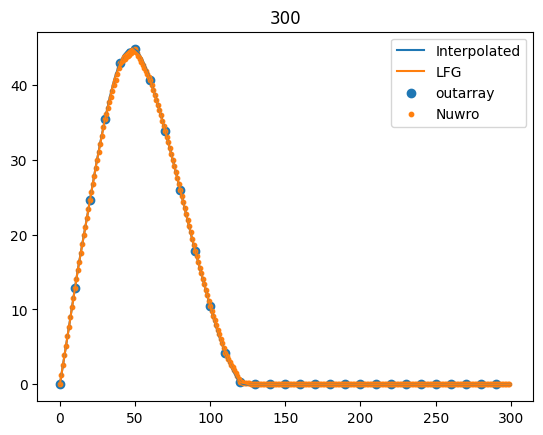

In [28]:
qidx = 30
qval = qcoords[qidx]
wcoords = np.linspace(0, lfg_data[qidx][0][0][-1], 100)
plt.plot(wcoords, funcs[0](qval, wcoords), label="Interpolated")
plt.plot(lfg_data[qidx][0][0], lfg_data[qidx][0][1], label="LFG")
indexes = modules.nuwro.Stupid_2D_to_1D(qidx, np.arange(0, 300, 10)/10, steps)
plotvals = []
for idx in indexes:
    idx = int(idx)
    plotvals.append(outarrays[0][idx])
print(plotvals)
plt.scatter(np.arange(0, 300, 10), plotvals, label="outarray")
plt.scatter(tempw, tempres, label="Nuwro", s=10)
plt.legend()
plt.title(qval)

In [39]:
wcoords

array([   0,   10,   20,   30,   40,   50,   60,   70,   80,   90,  100,
        110,  120,  130,  140,  150,  160,  170,  180,  190,  200,  210,
        220,  230,  240,  250,  260,  270,  280,  290,  300,  310,  320,
        330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
        440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,
        550,  560,  570,  580,  590,  600,  610,  620,  630,  640,  650,
        660,  670,  680,  690,  700,  710,  720,  730,  740,  750,  760,
        770,  780,  790,  800,  810,  820,  830,  840,  850,  860,  870,
        880,  890,  900,  910,  920,  930,  940,  950,  960,  970,  980,
        990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090,
       1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190])